# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).

---

*We would now like to understand exactly the difference between the expression in our groups of mice.*
*Which pipeline would you use for this?*

I would use the nf-core/differentialabundance pipeline because we already have gene expression counts from the RNA-seq analysis and now want to compare gene expression between different groups of samples. The pipeline can perform differential expression analysis and generate relevant downstream results and
visualizations.

---

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [1]:
# Load the expression matrix and inspect its structure
import pandas as pd

expression_matrix = pd.read_csv(
    "data/salmon.merged.gene_counts.tsv",
    sep="\t"
)

print("Shape:", expression_matrix.shape)
print("\nColumn names:")
print(expression_matrix.columns.tolist())

expression_matrix.head()

Shape: (45706, 18)

Column names:
['gene_id', 'gene_name', 'Sham_oxy_1', 'Sham_oxy_2', 'Sham_oxy_3', 'Sham_oxy_4', 'Sham_Sal_1', 'Sham_Sal_2', 'Sham_Sal_3', 'Sham_Sal_4', 'SNI_oxy_1', 'SNI_oxy_2', 'SNI_oxy_3', 'SNI_oxy_4', 'SNI_Sal_1', 'SNI_Sal_2', 'SNI_Sal_3', 'SNI_Sal_4']


,gene_id,gene_name,Sham_oxy_1,Sham_oxy_2,Sham_oxy_3,Sham_oxy_4,Sham_Sal_1,Sham_Sal_2,Sham_Sal_3,Sham_Sal_4,SNI_oxy_1,SNI_oxy_2,SNI_oxy_3,SNI_oxy_4,SNI_Sal_1,SNI_Sal_2,SNI_Sal_3,SNI_Sal_4
0,ENSMUSG00000000001,Gnai3,69.0,294.0,259.0,444.0,242.0,651.0,622.0,406.0,383.0,518.0,349.0,281.0,471.0,46.0,230.0,79.0
1,ENSMUSG00000000003,Pbsn,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ENSMUSG00000000028,Cdc45,1.0,10.0,2.0,6.0,15.0,15.0,22.0,12.0,9.0,15.0,9.0,8.0,12.0,6.0,5.0,5.0
3,ENSMUSG00000000031,H19,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0
4,ENSMUSG00000000037,Scml2,12.0,21.0,12.0,18.0,9.0,24.0,36.0,19.0,18.0,26.0,20.0,23.0,26.0,2.0,13.0,1.0


In [ ]:
# Get all sample names from the expression matrix
# gene_id and gene_name are annotation columns, not samples
sample_names = expression_matrix.columns[2:]

samplesheet = pd.DataFrame({
    "sample": sample_names
})

# Create the Condition column expected by contrasts.csv
# Example: Sham_oxy_1 -> Sham_oxy
#          SNI_Sal_3  -> SNI_Sal
samplesheet["Condition"] = samplesheet["sample"].str.rsplit("_", n=1).str[0]

samplesheet

,sample,Condition
0,Sham_oxy_1,Sham_oxy
1,Sham_oxy_2,Sham_oxy
2,Sham_oxy_3,Sham_oxy
3,Sham_oxy_4,Sham_oxy
4,Sham_Sal_1,Sham_Sal
5,Sham_Sal_2,Sham_Sal
6,Sham_Sal_3,Sham_Sal
7,Sham_Sal_4,Sham_Sal
8,SNI_oxy_1,SNI_oxy
9,SNI_oxy_2,SNI_oxy


In [ ]:

samplesheet.to_csv(
    "samplesheet.csv",
    index=False
)

print("Saved samplesheet.csv")

Saved samplesheet.csv


In [6]:

pd.read_csv("samplesheet.csv")

,sample,Condition
0,Sham_oxy_1,Sham_oxy
1,Sham_oxy_2,Sham_oxy
2,Sham_oxy_3,Sham_oxy
3,Sham_oxy_4,Sham_oxy
4,Sham_Sal_1,Sham_Sal
5,Sham_Sal_2,Sham_Sal
6,Sham_Sal_3,Sham_Sal
7,Sham_Sal_4,Sham_Sal
8,SNI_oxy_1,SNI_oxy
9,SNI_oxy_2,SNI_oxy


---

Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [1]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile rnaseq,docker \
    --genome GRCm38 \
    --input samplesheet.csv \
    --contrasts data/contrasts.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --outdir differentialabundance_results \
    -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [cranky_yalow] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : data/contrasts.csv
  outdir                      : differentialabundance_results
  study_abundance_type        : counts

[base] Abundance values
  matrix                      : data/salmon.merged.gene_counts.tsv

[base] Obse

---

*Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.*

**Parameters**

- `-r 2.0.0`: Specifies the version of the nf-core/differentialabundance pipeline. Using a fixed version makes the analysis reproducible.

- `-profile rnaseq,docker`: Uses the RNA-seq profile of the pipeline and Docker to provide the required software environments.

- `--genome GRCm38`: Specifies the mouse reference genome used for the analysis and provides the corresponding reference information.

- `--input samplesheet.csv`: Specifies the samplesheet containing the sample names and their experimental conditions.

- `--contrasts data/contrasts.csv`: Specifies the provided contrast file, which defines which experimental conditions should be compared.

- `--matrix data/salmon.merged.gene_counts.tsv`: Specifies the provided gene count matrix generated by Salmon. The rows represent genes and the sample columns contain their expression counts.

- `--features_id_col gene_id`: Specifies that the `gene_id` column contains the unique identifiers of the genes.

- `--features_name_col gene_name`: Specifies that the `gene_name` column contains the gene names.

- `--outdir differentialabundance_results`: Specifies the directory in which the pipeline outputs are stored.

**Additional input files**

The `samplesheet.csv` file was created from the sample names in the provided expression matrix. It assigns each sample to one of four conditions: `Sham_oxy`, `Sham_Sal`, `SNI_oxy`, or `SNI_Sal`.

The provided `contrasts.csv` file defines two comparisons: `SNI_oxy` versus `SNI_Sal` and `Sham_oxy` versus `Sham_Sal`.


---

*What were the outputs of the pipeline?*

In [2]:
# Check the differential expression results after rerunning the pipeline

from pathlib import Path
import pandas as pd

results_path = Path(
    "differentialabundance_results/tables/differential/rnaseq"
)

# Show all differential expression result files
for file in sorted(results_path.glob("*.tsv")):
    print(file.name)

condition_control_treated_study.deseq2.results.tsv
condition_control_treated_study.deseq2.results_filtered.tsv
condition_control_treated_study_deseq2.annotated.tsv
condition_control_treated_test_study.deseq2.results.tsv
condition_control_treated_test_study.deseq2.results_filtered.tsv
condition_control_treated_test_study_deseq2.annotated.tsv


In [8]:
# Load the filtered differential expression results
# produced by the pipeline

import pandas as pd

sni_filtered = pd.read_csv(
    "differentialabundance_results/tables/differential/rnaseq/"
    "condition_control_treated_study.deseq2.results_filtered.tsv",
    sep="\t"
)

sham_filtered = pd.read_csv(
    "differentialabundance_results/tables/differential/rnaseq/"
    "condition_control_treated_test_study.deseq2.results_filtered.tsv",
    sep="\t"
)

print("SNI_oxy vs SNI_Sal:", len(sni_filtered), "DEGs")
print("Sham_oxy vs Sham_Sal:", len(sham_filtered), "DEGs")

SNI_oxy vs SNI_Sal: 18 DEGs
Sham_oxy vs Sham_Sal: 7 DEGs


The pipeline produced several output directories containing the results of the differential expression analysis:
- tables: differential expression results and other result tables.
- plots: visualizations of the differential expression analysis.
- report: summary reports of the analysis.
- shinyngs_app: files for interactive exploration of the results.
- pipeline_info: information about the Nextflow run and software versions.
- other: additional intermediate or supporting output files.

---

*Would you exclude any samples? If yes, which and why?*

Yes. I would exclude `SNI_Sal_2` and `SNI_Sal_4`. In the sample clustering dendrogram, these two samples form a separate branch that is highly distant
from the remaining samples. The PCA also shows that both samples are strongly separated from the main sample cluster, particularly along PC1. Together,
these results indicate that `SNI_Sal_2` and `SNI_Sal_4` are likely outliers.

---

*How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?*

In [ ]:
# Use the differential expression results filtered by the pipeline

print("SNI_oxy vs SNI_Sal:", len(sni_filtered), "DEGs")
print("Sham_oxy vs Sham_Sal:", len(sham_filtered), "DEGs")

SNI_oxy vs SNI_Sal: 18 DEGs
Sham_oxy vs Sham_Sal: 7 DEGs


Using the adjusted results, 18 genes were differentially expressed in `SNI-Oxy` vs `SNI-Sal` and 7 genes were differentially expressed in
`Sham-Oxy` vs `Sham-Sal`.

The number of differentially expressed genes is relatively small. However, these results cannot be directly compared to the DEG numbers reported in
the publication because the publication analyzed the NAc, mPFC, and VTA brain regions separately, whereas the provided expression matrix does not
distinguish between brain regions.

---
*The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.*

**NAc (nucleus accumbens)** is a brain region involved in reward, motivation, and addiction.  
The **mPFC (medial prefrontal cortex)** is involved in higher cognitive functions such as decision-making, emotional regulation, and behavioral control.  
The **VTA (ventral tegmental area)** contains many dopamine-producing neurons and plays an important role in reward, motivation, and reinforcement.

---

*Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?*

No, not directly from the paper or the Materials and Methods. The authors performed RNA-seq on tissue collected from the NAc, mPFC and VTA, but the Methods do not provide a complete list of genes included or expressed in each region. This information would have to be obtained from the RNA-seq data and the corresponding gene annotations.

---

*Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?*

No, a list of differentially expressed genes alone would not be sufficient, because it does not directly explain their biological relevance. The publication therefore performed additional analyses such as Gene Ontology (GO) and Ingenuity Pathway Analysis (IPA) to identify affected biological processes, pathways, and upstream regulators.

---

*Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentioned.*

In [22]:
# Create the contrasts required for the Figure 3 Venn diagram

import pandas as pd

venn_contrasts = pd.DataFrame({
    "id": [
        "sham_oxy_vs_sham_sal",
        "sni_sal_vs_sham_sal",
        "sni_oxy_vs_sham_sal"
    ],
    "variable": [
        "Condition",
        "Condition",
        "Condition"
    ],
    "reference": [
        "Sham_Sal",
        "Sham_Sal",
        "Sham_Sal"
    ],
    "target": [
        "Sham_oxy",
        "SNI_Sal",
        "SNI_oxy"
    ]
})

venn_contrasts.to_csv(
    "contrasts_venn.csv",
    index=False
)

venn_contrasts

,id,variable,reference,target
0,sham_oxy_vs_sham_sal,Condition,Sham_Sal,Sham_oxy
1,sni_sal_vs_sham_sal,Condition,Sham_Sal,SNI_Sal
2,sni_oxy_vs_sham_sal,Condition,Sham_Sal,SNI_oxy


In [3]:
!nextflow run nf-core/differentialabundance \
    -r 2.0.0 \
    -profile rnaseq,docker \
    --genome GRCm38 \
    --input samplesheet.csv \
    --contrasts contrasts_venn.csv \
    --matrix data/salmon.merged.gene_counts.tsv \
    --features_id_col gene_id \
    --features_name_col gene_name \
    --outdir differentialabundance_venn_results \
    -resume


 N E X T F L O W   ~  version 26.04.6

Launching `https://github.com/nf-core/differentialabundance` [intergalactic_borg] revision: 30ed7741fc [2.0.0]

WARN: Unrecognized config option 'validation.defaultIgnoreParams'
WARN: Unrecognized config option 'validation.monochromeLogs'

------------------------------------------------------
                                        ,--./,-.
        ___     __   __   __   ___     /,-._.--~'
  |\ | |__  __ /  ` /  \ |__) |__         }  {
  | \| |       \__, \__/ |  \ |___     \`-._,-`-,
                                        `._,._,'
  nf-core/differentialabundance 2.0.0
------------------------------------------------------

[base] Input/output options
  input                       : samplesheet.csv
  contrasts                   : contrasts_venn.csv
  outdir                      : differentialabundance_venn_results
  study_abundance_type        : counts

[base] Abundance values
  matrix                      : data/salmon.merged.gene_counts.tsv



In [10]:
# Show the result files from the Figure 3 analysis

from pathlib import Path

results_dir = Path(
    "differentialabundance_venn_results/tables/differential/rnaseq"
)

for file in sorted(results_dir.glob("*.tsv")):
    print(file.name)

sham_oxy_vs_sham_sal_study.deseq2.results.tsv
sham_oxy_vs_sham_sal_study.deseq2.results_filtered.tsv
sham_oxy_vs_sham_sal_study_deseq2.annotated.tsv
sni_oxy_vs_sham_sal_study.deseq2.results.tsv
sni_oxy_vs_sham_sal_study.deseq2.results_filtered.tsv
sni_oxy_vs_sham_sal_study_deseq2.annotated.tsv
sni_sal_vs_sham_sal_study.deseq2.results.tsv
sni_sal_vs_sham_sal_study.deseq2.results_filtered.tsv
sni_sal_vs_sham_sal_study_deseq2.annotated.tsv


Number of DEGs using paper criteria:
Sham-Oxy vs Sham-Sal: 22
SNI-Sal vs Sham-Sal: 117
SNI-Oxy vs Sham-Sal: 1

Shared between all three contrasts: 1


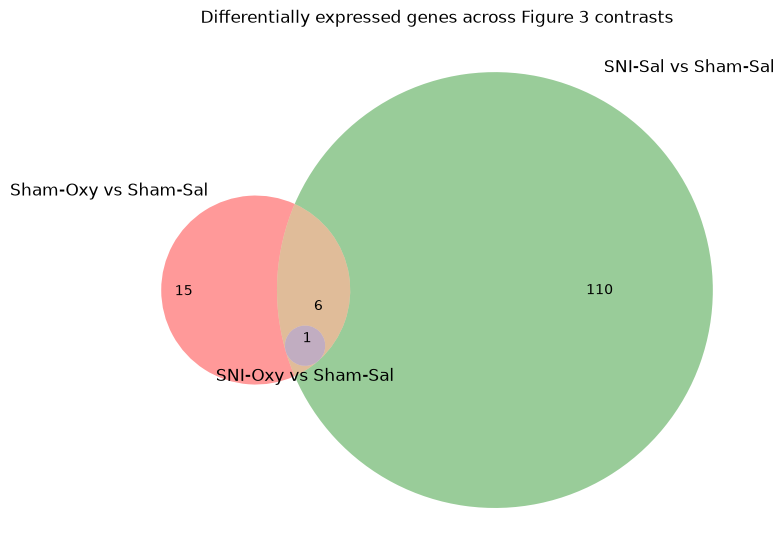

In [9]:
# Reproduce the Figure 3 Venn diagram using the DEG criteria
# reported in the paper: p < 0.05 and |log2FC| > 0.5

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
from pathlib import Path

# Folder containing the differential expression results
results_dir = Path(
    "differentialabundance_venn_results/tables/differential/rnaseq"
)

# Load the COMPLETE DESeq2 results for the three Figure 3 contrasts
sham_oxy = pd.read_csv(
    results_dir / "sham_oxy_vs_sham_sal_study.deseq2.results.tsv",
    sep="\t"
)

sni_sal = pd.read_csv(
    results_dir / "sni_sal_vs_sham_sal_study.deseq2.results.tsv",
    sep="\t"
)

sni_oxy = pd.read_csv(
    results_dir / "sni_oxy_vs_sham_sal_study.deseq2.results.tsv",
    sep="\t"
)

# Apply the DEG criteria used in the paper:
# p < 0.05 and |log2FoldChange| > 0.5
def filter_paper_degs(df):
    return df[
        (df["pvalue"] < 0.05) &
        (df["log2FoldChange"].abs() > 0.5)
    ].copy()


sham_oxy_deg = filter_paper_degs(sham_oxy)
sni_sal_deg = filter_paper_degs(sni_sal)
sni_oxy_deg = filter_paper_degs(sni_oxy)

# Create sets of gene IDs
sham_oxy_genes = set(sham_oxy_deg["gene_id"].dropna())
sni_sal_genes = set(sni_sal_deg["gene_id"].dropna())
sni_oxy_genes = set(sni_oxy_deg["gene_id"].dropna())

# Print DEG numbers
print("Number of DEGs using paper criteria:")
print(f"Sham-Oxy vs Sham-Sal: {len(sham_oxy_genes)}")
print(f"SNI-Sal vs Sham-Sal: {len(sni_sal_genes)}")
print(f"SNI-Oxy vs Sham-Sal: {len(sni_oxy_genes)}")

# Calculate overlap between all three contrasts
shared_all = sham_oxy_genes & sni_sal_genes & sni_oxy_genes

print(f"\nShared between all three contrasts: {len(shared_all)}")

# Create three-way Venn diagram
plt.figure(figsize=(8, 8))

venn3(
    [sham_oxy_genes, sni_sal_genes, sni_oxy_genes],
    set_labels=(
        "Sham-Oxy vs Sham-Sal",
        "SNI-Sal vs Sham-Sal",
        "SNI-Oxy vs Sham-Sal"
    )
)

plt.title("Differentially expressed genes across Figure 3 contrasts")

plt.tight_layout()

plt.savefig(
    "venn_diagram_figure3.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

The Venn diagram compares the three contrasts shown in Figure 3 of the publication, without separating the samples by brain region. Differentially expressed genes were defined using the criteria reported in the paper (P < 0.05 and |log2FC| > 0.5).

The analysis identified 22 DEGs for `Sham-Oxy` vs `Sham-Sal`, 117 DEGs for `SNI-Sal` vs `Sham-Sal`, and 1 DEG for `SNI-Oxy` vs `Sham-Sal`. One gene was shared between all three contrasts.